In [14]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

In [15]:
# Load data
df = pd.read_csv("Job_Tweets.csv")
df.head()

,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Location,Verified_Account,Followers,Following
0,1211798864656769025,2019-12-30 23:58:58+00:00,SipapuNM,Looking for an exciting job where you can ski ...,NaN,0,1,0,"<a href=""http://instagram.com"" rel=""nofollow"">...","20 miles SE of Taos, NM",False,3342,258
1,1211797371853705220,2019-12-30 23:53:02+00:00,LorettaOD1,Hail in Phoenix - no way! New opportunity at ...,['job'],0,0,0,"<a href=""http://jobvite.com"" rel=""nofollow"">Jo...",Arizona,False,63,129
2,1211795775363145728,2019-12-30 23:46:41+00:00,guajardo_celina,Rackspace is hiring! We are looking for Nation...,"['becomearacker', 'Rackspace', 'recruiting', '...",0,0,0,"<a href=""http://jobvite.com"" rel=""nofollow"">Jo...","Texas, USA",False,19,50
3,1211793355060981767,2019-12-30 23:37:04+00:00,SteveEckert_OTD,We are #hiring Administrative Assistant in Nan...,"['hiring', 'jobs', 'Nanuet']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Orange County, California",False,966,1569
4,1211792689022349315,2019-12-30 23:34:25+00:00,HireLive,We are #hiring Family Service Counselor in Irv...,"['hiring', 'jobs', 'Irvine']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",United States,False,983,1251


#EDA

In [16]:
df.shape

(50000, 13)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                50000 non-null  int64 
 1   Timestamp         50000 non-null  object
 2   User              50000 non-null  object
 3   Text              50000 non-null  object
 4   Hashtag           40684 non-null  object
 5   Retweets          50000 non-null  int64 
 6   Likes             50000 non-null  int64 
 7   Replies           50000 non-null  int64 
 8   Source            50000 non-null  object
 9   Location          44011 non-null  object
 10  Verified_Account  50000 non-null  bool  
 11  Followers         50000 non-null  int64 
 12  Following         50000 non-null  int64 
dtypes: bool(1), int64(6), object(6)
memory usage: 4.6+ MB


In [18]:
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Total duplicate rows: {df.duplicated().sum()}")

Total missing values: 15305
Total duplicate rows: 0


In [19]:
# Display data quality summary before cleaning
pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Null Count': df.isnull().sum().values
})

# Remove duplicate records (keeping rows with NaN in 'Hashtag')
df = df.dropna(subset=[col for col in df.columns if col != 'Hashtag'])
df = df.drop_duplicates()

# Display data quality summary after cleaning
pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Null Count': df.isnull().sum().values
})

,Feature,Data Type,Null Count
0,ID,int64,0
1,Timestamp,object,0
2,User,object,0
3,Text,object,0
4,Hashtag,object,7379
5,Retweets,int64,0
6,Likes,int64,0
7,Replies,int64,0
8,Source,object,0
9,Location,object,0


In [20]:
# Remove unused columns
df = df.drop(columns=['Location'], errors='ignore')

# Add Engagement column
engagement = df['Likes'] + df['Retweets'] + df['Replies']
df['Engagement'] = engagement

In [8]:
df.head()

,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Verified_Account,Followers,Following,Engagement
0,1211798864656769025,2019-12-30 23:58:58+00:00,SipapuNM,Looking for an exciting job where you can ski ...,NaN,0.0,1.0,0.0,"<a href=""http://instagram.com"" rel=""nofollow"">...",False,3342.0,258.0,1.0
1,1211797371853705220,2019-12-30 23:53:02+00:00,LorettaOD1,Hail in Phoenix - no way! New opportunity at ...,['job'],0.0,0.0,0.0,"<a href=""http://jobvite.com"" rel=""nofollow"">Jo...",False,63.0,129.0,0.0
2,1211795775363145728,2019-12-30 23:46:41+00:00,guajardo_celina,Rackspace is hiring! We are looking for Nation...,"['becomearacker', 'Rackspace', 'recruiting', '...",0.0,0.0,0.0,"<a href=""http://jobvite.com"" rel=""nofollow"">Jo...",False,19.0,50.0,0.0
3,1211793355060981767,2019-12-30 23:37:04+00:00,SteveEckert_OTD,We are #hiring Administrative Assistant in Nan...,"['hiring', 'jobs', 'Nanuet']",0.0,0.0,0.0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",False,966.0,1569.0,0.0
4,1211792689022349315,2019-12-30 23:34:25+00:00,HireLive,We are #hiring Family Service Counselor in Irv...,"['hiring', 'jobs', 'Irvine']",0.0,0.0,0.0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",False,983.0,1251.0,0.0


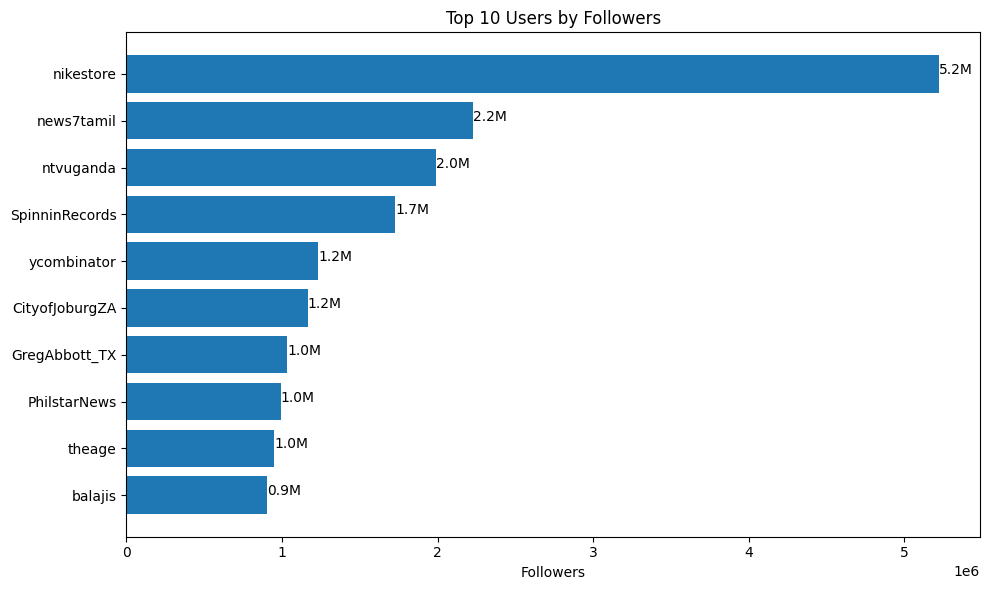

          User  Followers
     nikestore    5226473
    news7tamil    2224877
     ntvuganda    1991358
SpinninRecords    1727773
   ycombinator    1234555
CityofJoburgZA    1164120
 GregAbbott_TX    1033517
  PhilstarNews     993123
        theage     951224
       balajis     901122


In [21]:
# Identify top users by follower count
top_users = (
    df[['User', 'Followers']]
    .drop_duplicates()
    .nlargest(10, 'Followers')
)

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_users['User'], top_users['Followers'])
ax.invert_yaxis()

ax.set_title('Top 10 Users by Followers')
ax.set_xlabel('Followers')

# Add data labels
for _, row in top_users.iterrows():
    ax.text(
        row['Followers'],
        row['User'],
        f"{row['Followers'] / 1_000_000:.1f}M"
    )

plt.tight_layout()
plt.show()

# Display results
print(top_users.to_string(index=False))

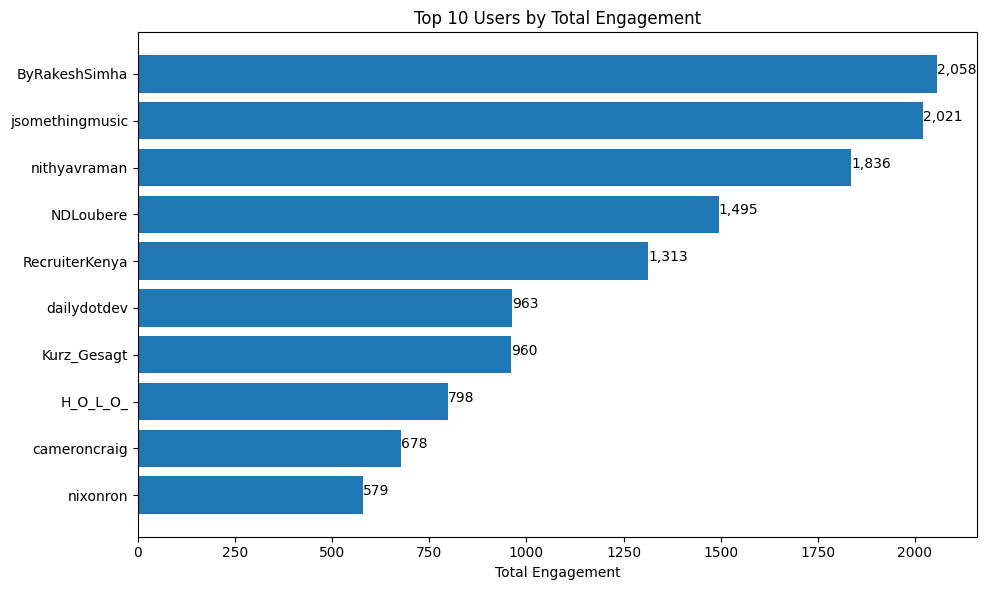

           User  Engagement
  ByRakeshSimha        2058
jsomethingmusic        2021
   nithyavraman        1836
      NDLoubere        1495
 RecruiterKenya        1313
    dailydotdev         963
    Kurz_Gesagt         960
       H_O_L_O_         798
   cameroncraig         678
       nixonron         579


In [22]:
# Identify top users by total engagement
top_users = (
    df.groupby('User', as_index=False)['Engagement']
    .sum()
    .nlargest(10, 'Engagement')
)

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_users['User'], top_users['Engagement'])
ax.invert_yaxis()

ax.set_title('Top 10 Users by Total Engagement')
ax.set_xlabel('Total Engagement')

# Add data labels
for _, row in top_users.iterrows():
    ax.text(
        row['Engagement'],
        row['User'],
        f"{row['Engagement']:,}"
    )

plt.tight_layout()
plt.show()

# Display results
print(top_users.to_string(index=False))

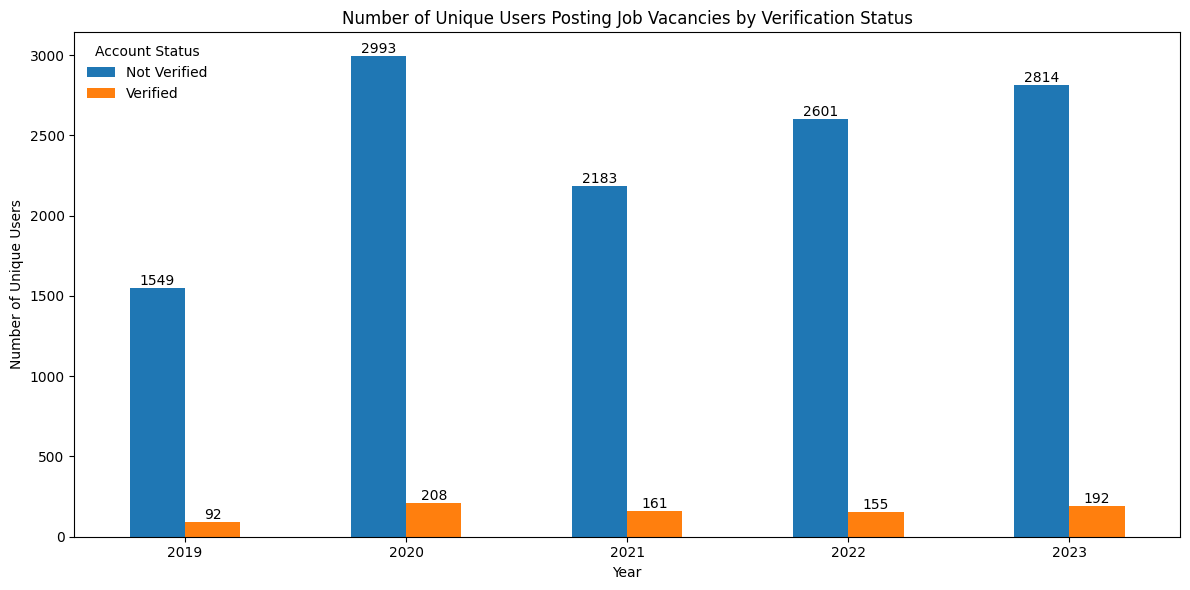

Number of Unique Users Posting Job Vacancies by Verification Status:
Account_Status  Not Verified  Verified
Year                                  
2019                    1549        92
2020                    2993       208
2021                    2183       161
2022                    2601       155
2023                    2814       192


In [23]:
# Extract year from timestamp
df['Year'] = pd.to_datetime(df['Timestamp']).dt.year

# Create account status labels
df['Account_Status'] = df['Verified_Account'].map({
    True: 'Verified',
    False: 'Not Verified'
})

# Count unique users by year and account status
user_counts = (
    df.assign(User=df['User'].astype(str))
    .groupby(['Year', 'Account_Status'])['User']
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=['Not Verified', 'Verified'], fill_value=0)
)

# Create chart
fig, ax = plt.subplots(figsize=(12, 6))

user_counts.plot(
    kind='bar',
    ax=ax,
    rot=0
)

ax.set_title('Number of Unique Users Posting Job Vacancies by Verification Status')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Unique Users')
ax.legend(title='Account Status', frameon=False)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

# Display results
print('Number of Unique Users Posting Job Vacancies by Verification Status:')
print(user_counts.to_string())

Number of Job Postings Per Year:
 Year  Post_Count
 2019        8790
 2020        8971
 2021        9223
 2022        8338
 2023        8689


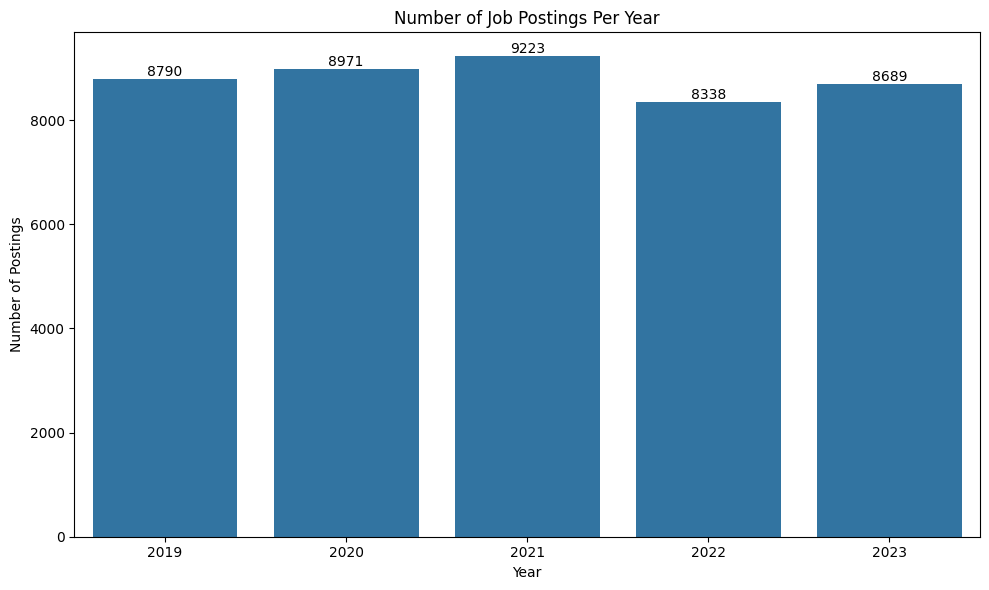

In [24]:
# Extract year from timestamp
df['Year'] = pd.to_datetime(df['Timestamp']).dt.year

# Count job postings by year
posts_per_year = (
    df.groupby('Year')
    .size()
    .reset_index(name='Post_Count')
)

# Display results
print('Number of Job Postings Per Year:')
print(posts_per_year.to_string(index=False))

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=posts_per_year,
    x='Year',
    y='Post_Count',
    ax=ax
)

ax.set_title('Number of Job Postings Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Postings')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

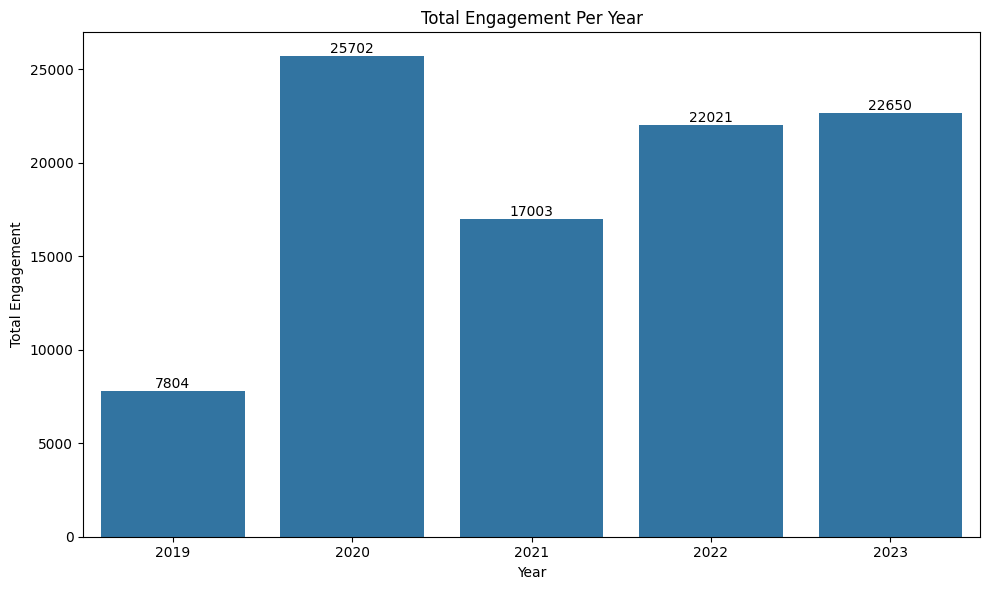

Total Engagement Per Year:
 Year  Total_Engagement
 2019              7804
 2020             25702
 2021             17003
 2022             22021
 2023             22650


In [25]:
# Calculate yearly engagement metrics
yearly_metrics = (
    df.groupby('Year')
    .agg(
        Total_Engagement=('Engagement', 'sum'),
        Post_Count=('ID', 'count')
    )
    .reset_index()
)

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=yearly_metrics,
    x='Year',
    y='Total_Engagement',
    ax=ax
)

ax.set_title('Total Engagement Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Total Engagement')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

# Display results
print('Total Engagement Per Year:')
print(
    yearly_metrics[
        ['Year', 'Total_Engagement']
    ].to_string(index=False)
)

Number of Job Postings by Day of the Week:
Day  Post_Count
Mon        7563
Tue        8462
Wed        7812
Thu        7505
Fri        7248
Sat        3194
Sun        2227


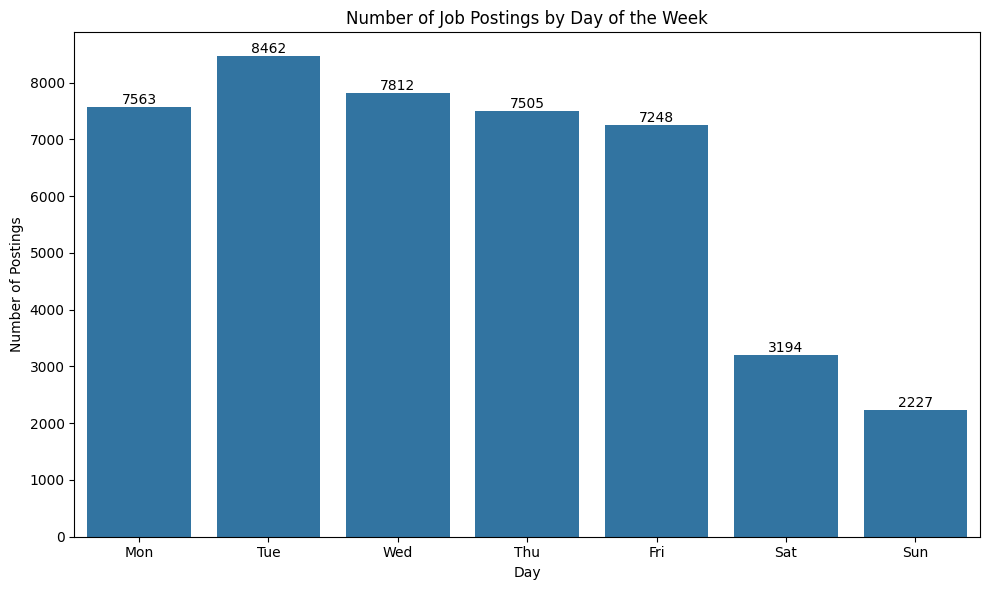

In [26]:
# Extract day of week from timestamp
df['Day_of_Week'] = pd.to_datetime(df['Timestamp']).dt.day_name().str[:3]

# Define day order
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Count job postings by day of week
posts_per_day = (
    df['Day_of_Week']
    .value_counts()
    .reindex(day_order, fill_value=0)
    .reset_index()
)

posts_per_day.columns = ['Day', 'Post_Count']

# Display results
print('Number of Job Postings by Day of the Week:')
print(posts_per_day.to_string(index=False))

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=posts_per_day,
    x='Day',
    y='Post_Count',
    ax=ax
)

ax.set_title('Number of Job Postings by Day of the Week')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Postings')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

Total Engagement Per Day of the Week:
Day_of_Week  Engagement
        Mon       17348
        Tue       21403
        Wed       15120
        Thu       17847
        Fri       12666
        Sat        6780
        Sun        4016


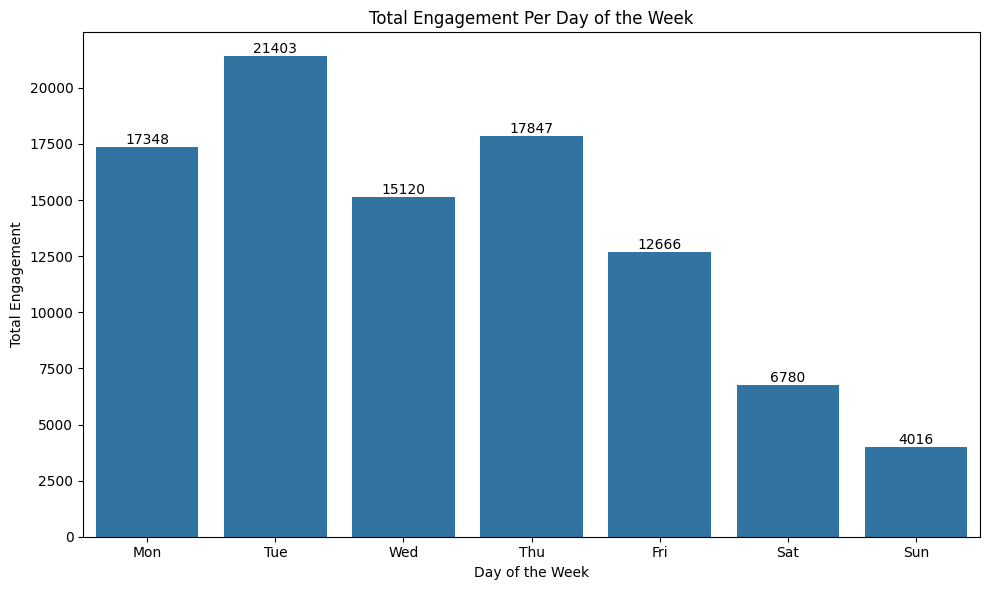

In [31]:
# Calculate total engagement by day of week
daily_engagement = (
    df.groupby('Day_of_Week')['Engagement']
    .sum()
    .reindex(day_order, fill_value=0)
    .reset_index()
)

# Display results
print('Total Engagement Per Day of the Week:')
print(daily_engagement.to_string(index=False))

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=daily_engagement,
    x='Day_of_Week',
    y='Engagement',
    ax=ax
)

ax.set_title('Total Engagement Per Day of the Week')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Total Engagement')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

Number of Job Postings by Hour:
 Hour  Post_Count
    0        1114
    1         927
    2         754
    3         838
    4        1124
    5         797
    6         750
    7         754
    8         865
    9        1183
   10        1442
   11        1199
   12        1550
   13        2028
   14        3171
   15        3120
   16        3231
   17        3120
   18        3061
   19        2836
   20        3199
   21        2830
   22        2439
   23        1679


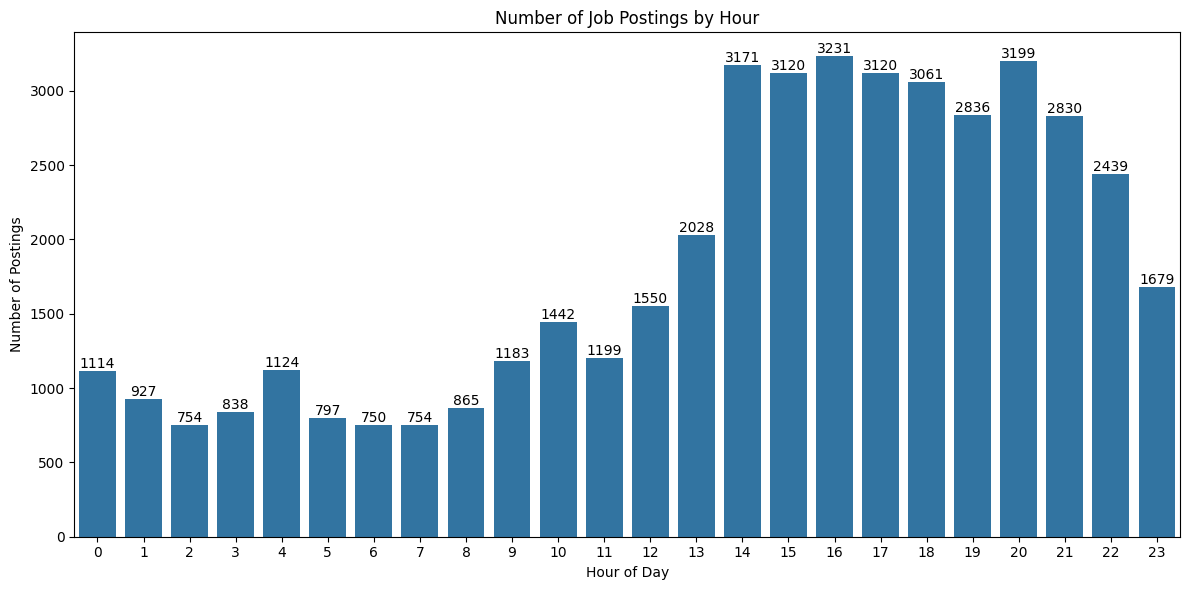

In [28]:
# Extract hour from timestamp
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour

# Count job postings by hour
posts_per_hour = (
    df['Hour']
    .value_counts()
    .sort_index()
    .reindex(range(24), fill_value=0)
    .reset_index()
)

posts_per_hour.columns = ['Hour', 'Post_Count']

# Display results
print('Number of Job Postings by Hour:')
print(posts_per_hour.to_string(index=False))

# Create chart
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=posts_per_hour,
    x='Hour',
    y='Post_Count',
    ax=ax
)

ax.set_title('Number of Job Postings by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Postings')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

Total Engagement Per Hour:
 Hour  Total_Engagement
    0              3018
    1              1199
    2              1187
    3              1310
    4              1460
    5              1628
    6              1646
    7              3720
    8              3520
    9              3633
   10              5224
   11              4248
   12              4978
   13              7175
   14              6110
   15              6134
   16              6060
   17              6949
   18              5477
   19              3363
   20              4502
   21              6472
   22              2552
   23              3615


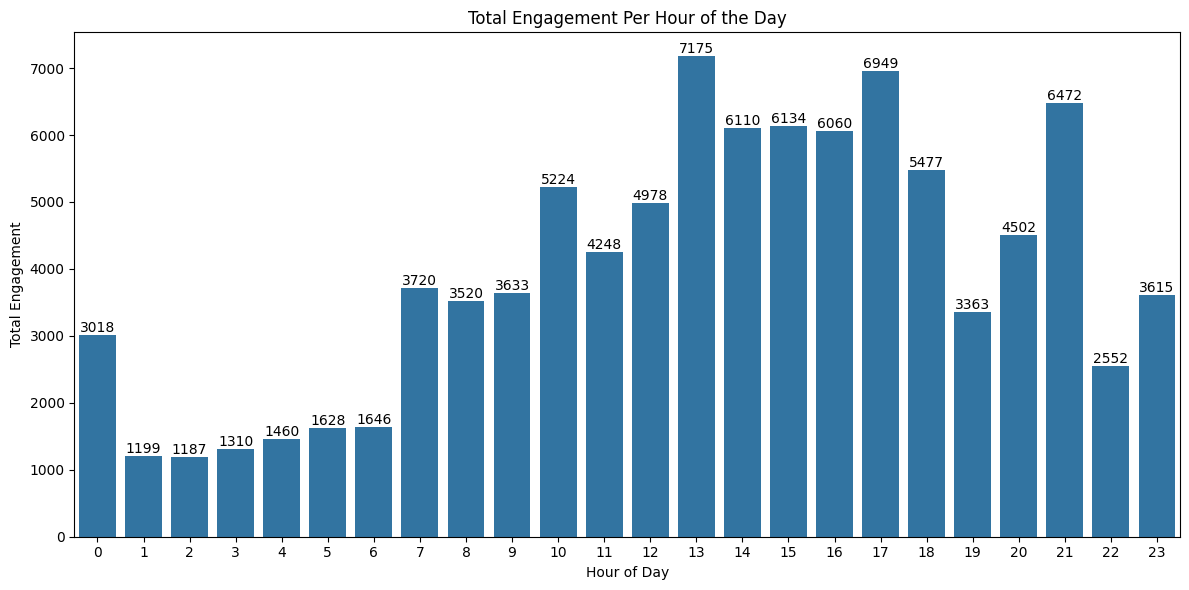

In [30]:
# Calculate total engagement by hour
hourly_engagement = (
    df.groupby('Hour')['Engagement']
    .sum()
    .reindex(range(24), fill_value=0)
    .reset_index()
)

hourly_engagement.columns = ['Hour', 'Total_Engagement']

# Display results
print('Total Engagement Per Hour:')
print(hourly_engagement.to_string(index=False))

# Create chart
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=hourly_engagement,
    x='Hour',
    y='Total_Engagement',
    ax=ax
)

ax.set_title('Total Engagement Per Hour of the Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Engagement')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [32]:
# Create verification status labels
df['Account_Status'] = df['Verified_Account'].map({
    True: 'Verified',
    False: 'Not Verified'
})

# Extract top 10 posts by total engagement
top_posts_engagement = df.nlargest(
    10,
    'Engagement'
)[['User', 'Account_Status', 'Text', 'Timestamp', 'Engagement']]

# Display results for Engagement
print(f'Top 10 Posts by Total Engagement:')
display(top_posts_engagement)
print('\n' + '-' * 50 + '\n')

Top 10 Posts by Total Engagement:


,User,Account_Status,Text,Timestamp,Engagement
35825,ByRakeshSimha,Not Verified,Dubai has stopped hiring Bangladeshis. My cous...,2022-12-13 13:15:32+00:00,2058
32994,jsomethingmusic,Verified,WE ARE HIRING!! \n\nA lot of you asked for job...,2022-12-20 17:33:50+00:00,2021
11657,nithyavraman,Verified,One great privilege of my new job is the oppor...,2020-12-21 21:03:32+00:00,1836
46192,NDLoubere,Not Verified,Since we are once again submerged in Swedish p...,2023-03-25 21:01:49+00:00,1495
41744,RecruiterKenya,Not Verified,We are hiring.\n\nRole - Admin/ Personal Assis...,2023-04-06 07:06:43+00:00,1257
45299,dailydotdev,Not Verified,Are you looking for a Job? \n\nWe are hiring!\...,2023-03-28 18:00:01+00:00,963
31122,Kurz_Gesagt,Verified,We are hiring! kurzgesagt is looking for a hea...,2022-12-27 14:01:19+00:00,960
27926,H_O_L_O_,Verified,#Holo is #hiring! We are looking for a Front-E...,2021-12-09 18:31:05+00:00,798
14662,nixonron,Verified,Come and join my team! We are hiring a video j...,2020-12-07 20:31:17+00:00,579
14827,idapgop,Not Verified,We are hiring! Please follow the link below to...,2020-12-07 08:32:05+00:00,576



--------------------------------------------------



Top 10 Most Frequent Sources:


,Count
Cleaned_Source,
ZipRecruiter Post Jobs,20407
Twitter Web App,7288
Hootsuite Inc.,2881
MightyRecruiter,1664
Twitter for iPhone,1572
Jobvite,1093
Twitter for Android,1032
Sprout Social,790
dlvr.it,778


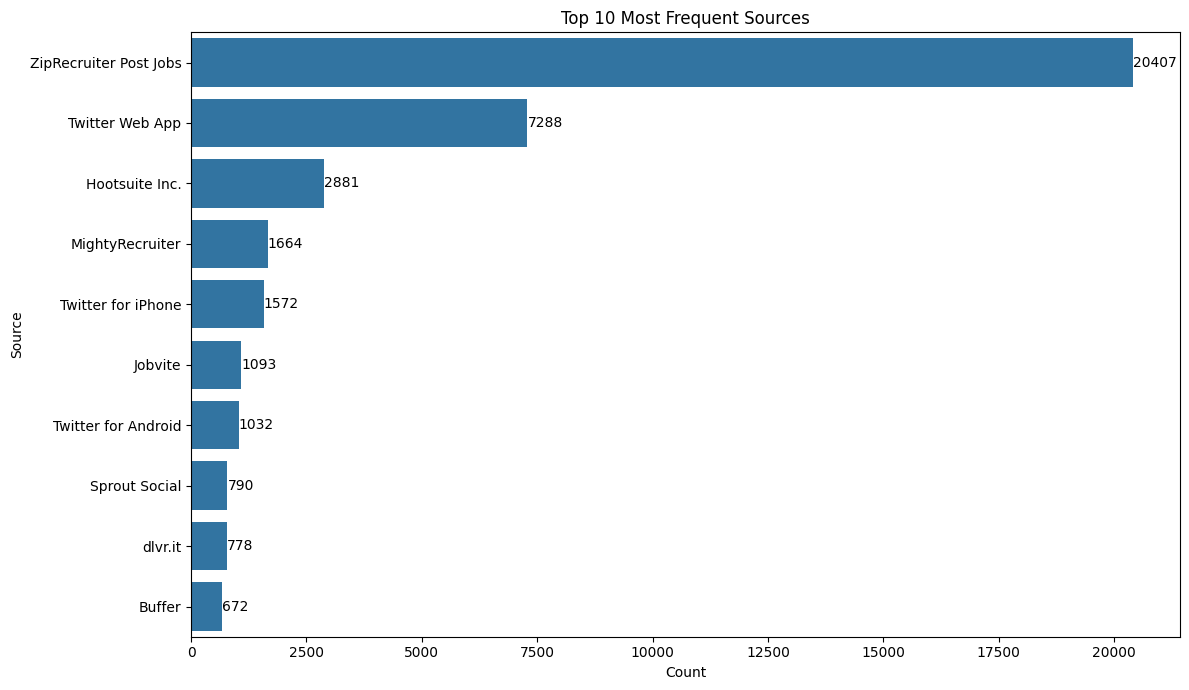

In [33]:
# Extract source names from HTML tags
df['Cleaned_Source'] = df['Source'].str.extract(r'>([^<]+)<', expand=False)

# Get the top 10 most frequent sources
top_sources = df['Cleaned_Source'].value_counts().head(10)

print('Top 10 Most Frequent Sources:')
display(top_sources.to_frame(name='Count'))

# Create horizontal bar chart
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_sources.values,
    y=top_sources.index
)

plt.title('Top 10 Most Frequent Sources')
plt.xlabel('Count')
plt.ylabel('Source')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

Top 10 Most Engaging Sources:


,Total Engagement
Cleaned_Source,
Twitter Web App,43587
Twitter for iPhone,19237
Twitter for Android,7352
Hootsuite Inc.,6408
ZipRecruiter Post Jobs,3957
TweetDeck,2362
Buffer,2336
Sprout Social,1786
HubSpot,630


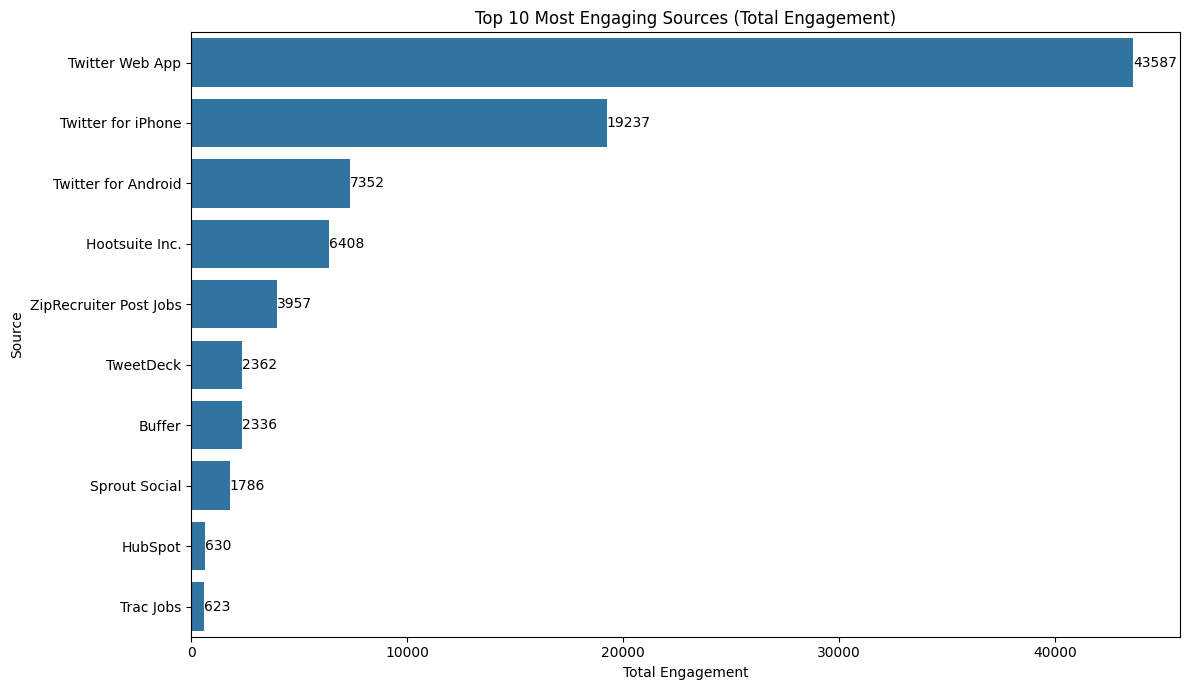

In [36]:
# Extract source names from HTML tags
df['Cleaned_Source'] = df['Source'].str.extract(r'>([^<]+)<', expand=False)

# Group by cleaned source and sum the total engagement
source_engagement = (
    df.groupby('Cleaned_Source')['Engagement']
    .sum()
    .nlargest(10)
)

print('Top 10 Most Engaging Sources:')
display(source_engagement.to_frame(name='Total Engagement'))

# Create horizontal bar chart
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=source_engagement.values,
    y=source_engagement.index
)

plt.title('Top 10 Most Engaging Sources (Total Engagement)')
plt.xlabel('Total Engagement')
plt.ylabel('Source')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

Number of Posts With and Without Hashtags (from original data):
 Hashtag Status  Count
   With Hashtag  36632
Without Hashtag   7379


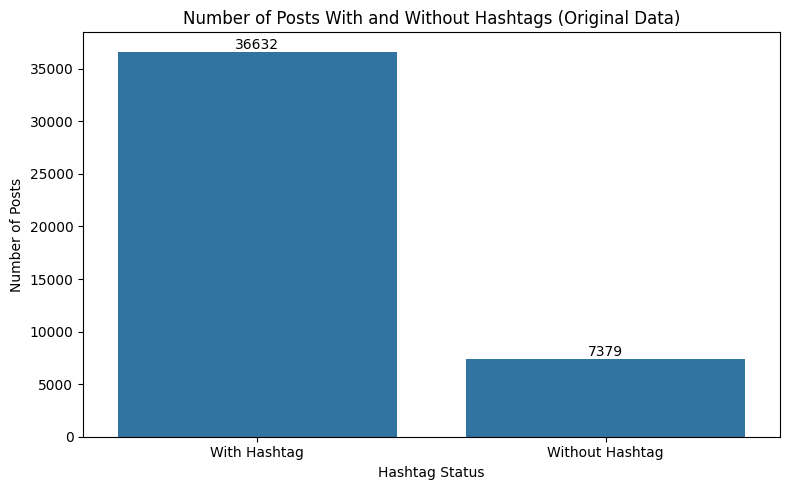

In [37]:
# Count posts with and without hashtags from the original DataFrame
hashtag_counts = df['Hashtag'].notna().value_counts().rename(index={True: 'With Hashtag', False: 'Without Hashtag'})
hashtag_df = hashtag_counts.reset_index()
hashtag_df.columns = ['Hashtag Status', 'Count']

print("Number of Posts With and Without Hashtags (from original data):")
print(hashtag_df.to_string(index=False))

# Create a bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Hashtag Status', y='Count', data=hashtag_df)
plt.title('Number of Posts With and Without Hashtags (Original Data)')
plt.xlabel('Hashtag Status')
plt.ylabel('Number of Posts')

# Add value labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

Total Engagement for Posts With and Without Hashtags (from original data):
 Hashtag Status  Total Engagement
Without Hashtag             46516
   With Hashtag             48664


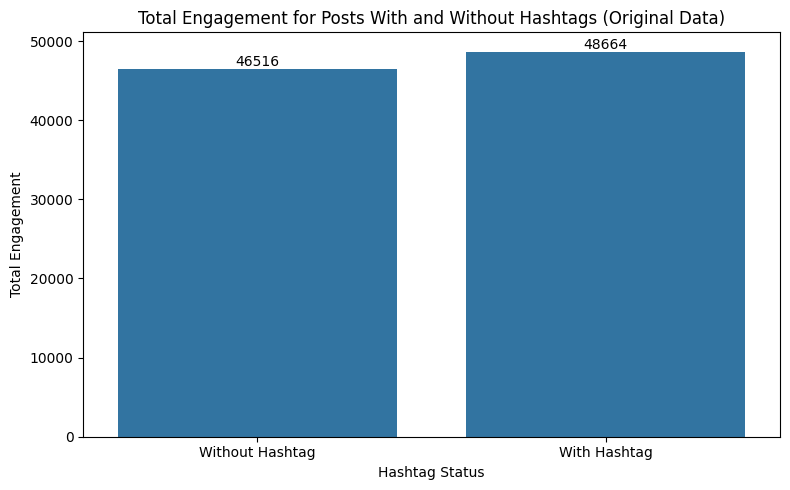

In [38]:
# Group by hashtag presence and sum engagement
hashtag_engagement = (
    df.groupby(df['Hashtag'].notna())['Engagement']
    .sum()
    .rename(index={True: 'With Hashtag', False: 'Without Hashtag'})
    .reset_index()
)
hashtag_engagement.columns = ['Hashtag Status', 'Total Engagement']

print("Total Engagement for Posts With and Without Hashtags (from original data):")
print(hashtag_engagement.to_string(index=False))

# Create a bar chart for total engagement
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Hashtag Status', y='Total Engagement', data=hashtag_engagement)
plt.title('Total Engagement for Posts With and Without Hashtags (Original Data)')
plt.xlabel('Hashtag Status')
plt.ylabel('Total Engagement')

# Add value labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [39]:
# Combine all text
all_text = ' '.join(df['Text'].fillna('').astype(str))

# Clean text
all_text = all_text.lower()
all_text = re.sub(r'http\S+|www\S+', '', all_text)
all_text = re.sub(r'@\w+|#\w+', '', all_text)
all_text = re.sub(r'[^a-z\s]', ' ', all_text)

# Count words
word_counts = Counter(all_text.split())

# Top 200 most frequent words
top_words = (
    pd.DataFrame(
        word_counts.items(),
        columns=['Word', 'Count']
    )
    .sort_values('Count', ascending=False)
)

top_words.head(10)

,Word,Count
13,are,47901
12,we,47893
23,in,29034
39,to,20151
1,for,18903
15,hiring,17935
36,and,16704
16,the,16656
31,a,16304
4,job,13252


In [40]:
# Save the top_words DataFrame to a CSV file
top_words.to_csv('word_frequencies.csv', index=False)

print("Word frequencies saved to word_frequencies.csv")

Word frequencies saved to word_frequencies.csv


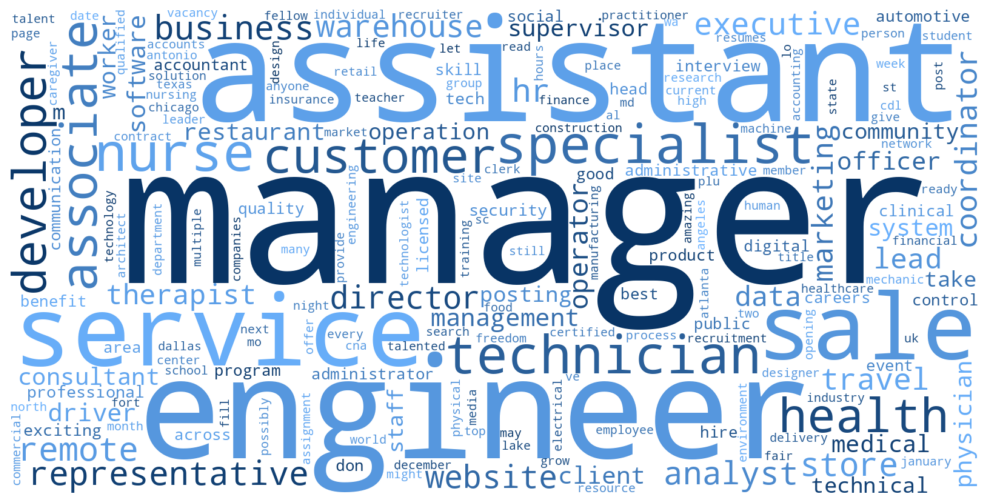


Top 20 Most Frequent Words (after stopword removal, as in word cloud):
          Word  Count
       manager   5430
     assistant   2486
      engineer   2449
         sales   2151
       service   1810
    specialist   1401
         nurse   1319
    technician   1260
     associate   1246
        health   1169
      customer   1108
      business    999
        remote    991
     developer    984
representative    947
         store    932
       analyst    890
      director    888
       website    879
     warehouse    864


In [41]:
# Combine all post text
all_text = ' '.join(df['Text'].fillna('').astype(str))

# Clean text
cleaned_text = all_text.lower()

# Remove URLs
cleaned_text = re.sub(r'http\S+|www\S+', '', cleaned_text)

# Remove hashtags and mentions
cleaned_text = re.sub(r'#\w+|@\w+', '', cleaned_text)

# Remove numbers and punctuation
cleaned_text = re.sub(r'\d+', '', cleaned_text)
cleaned_text = re.sub(r'[^a-zA-Z\s]', ' ', cleaned_text)

# Remove extra spaces
cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

# Custom stopwords for job vacancy posts
job_stopwords = [
    'a', 'about', 'account', 'alert', 'all', 'amp', 'an', 'and', 'april', 'application',
    'applications', 'apply', 'are', 'as', 'asked', 'at', 'available', 'az', 'based', 'be', 'below',
    'bonus', 'by', 'ca', 'call', 'called', 'can', 'candidates', 'career', 'care', 'check',
    'city', 'click', 'co', 'columbus', 'com', 'come', 'company', 'contact', 'currently',
    'cv', 'd', 'day', 'deadline', 'description', 'details', 'development', 'do', 'donor',
    'email', 'entry', 'experienced', 'experience', 'family', 'field', 'find', 'fl', 'follow', 'following',
    'for', 'from', 'full', 'ga', 'general', 'get', 'great', 'growing', 'gt', 'hail', 'have',
    'help', 'here', 'hit', 'home', 'houston', 'hour', 'how', 'hiring', 'id', 'if',
    'il', 'info', 'information', 'in', 'interested', 'is', 'it', 'job', 'jobs', 'join',
    'k', 'know', 'la', 'learn', 'level', 'like', 'link', 'lives', 'location', 'look', 'looking', 'lot',
    'love', 'lt', 'ma', 'maintenance', 'make', 'makes', 'mi', 'mn', 'more', 'n',
    'nc', 'need', 'net', 'new', 'nj', 'no', 'now', 'ny', 'of', 'office', 'oh',
    'on', 'online', 'one', 'open', 'openings', 'opportunities', 'opportunity', 'or',
    'our', 'out', 'pa', 'pay', 'part', 'passionate', 'people', 'per', 'phoenix', 'please', 'pm', 'position',
    'positions', 'possible', 'production', 'project', 're', 'registered', 'recruiting',
    'resume', 'retweet', 'right', 'rn', 'role', 'roles', 's', 'salary', 'san',
    'sandton', 'save', 'see', 'seeking', 'send', 'senior', 'share', 'shift', 'sign',
    'someone', 'sr', 'start', 'support', 't', 'talk', 'team', 'th', 'that', 'the', 'this',
    'time', 'tissue', 'today', 'to', 'tx', 'us', 'va', 'view', 'visit', 'want',
    'way', 'we', 'well', 'what', 'who', 'wi', 'will', 'with', 'work', 'working',
    'would', 'year', 'years', 'york', 'you', 'your'
]

# Combine default and custom stopwords
stopwords = STOPWORDS.union(job_stopwords)

# Define the custom colormap with colors reversed for desired effect
colors = ["#083464", "#6bb2ff"]
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)

# Generate word cloud with custom colormap
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=stopwords,
    collocations=False,
    colormap=cmap # Apply the custom colormap
).generate(cleaned_text)

# Display word cloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title('Most Common Terms in Job Vacancy Posts')
plt.tight_layout()
plt.show()

# Filter words based on the combined stopwords and count frequencies
filtered_words = [word for word in cleaned_text.split() if word not in stopwords]
filtered_word_counts = Counter(filtered_words)
top_words_filtered = (
    pd.DataFrame(
        filtered_word_counts.items(),
        columns=['Word', 'Count']
    )
    .sort_values('Count', ascending=False)
)

print("\nTop 20 Most Frequent Words (after stopword removal, as in word cloud):")
print(top_words_filtered.head(20).to_string(index=False))

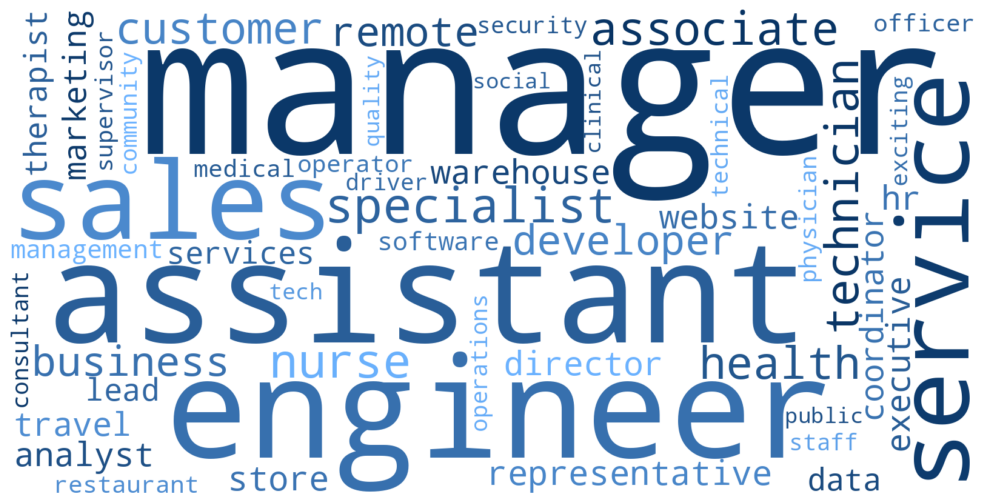


Top 50 Most Frequent Words (as shown in word cloud):
          Word  Count
       manager   5430
     assistant   2486
      engineer   2449
         sales   2151
       service   1810
    specialist   1401
         nurse   1319
    technician   1260
     associate   1246
        health   1169
      customer   1108
      business    999
        remote    991
     developer    984
representative    947
         store    932
       analyst    890
      director    888
       website    879
     warehouse    864
            hr    859
     executive    815
        travel    814
   coordinator    793
     marketing    751
          data    709
          lead    697
      services    686
     therapist    674
    management    655
      software    646
       medical    585
       officer    583
    restaurant    570
      operator    568
     physician    545
    supervisor    543
    operations    520
     community    519
     technical    518
         staff    506
    consultant    497


In [42]:
# Combine all post text
all_text = ' '.join(df['Text'].fillna('').astype(str))

# Clean text
cleaned_text = all_text.lower()
cleaned_text = re.sub(r'http\S+|www\S+', '', cleaned_text)
cleaned_text = re.sub(r'#\w+|@\w+', '', cleaned_text)
cleaned_text = re.sub(r'\d+', '', cleaned_text)
cleaned_text = re.sub(r'[^a-zA-Z\s]', ' ', cleaned_text)
cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

# Custom stopwords for job vacancy posts
job_stopwords = [
    'a', 'about', 'account', 'alert', 'all', 'amp', 'an', 'and', 'announce', 'anyone', 'april', 'application',
    'applications', 'apply', 'are', 'as', 'asked', 'at', 'available', 'az', 'based', 'be', 'below',
    'bonus', 'by', 'ca', 'call', 'called', 'can', 'candidates', 'career', 'care', 'check',
    'city', 'click', 'co', 'columbus', 'com', 'come', 'company', 'contact', 'currently',
    'cv', 'd', 'day', 'deadline', 'description', 'details', 'development', 'do', 'don', 'donor',
    'email', 'entry', 'excited', 'experienced', 'experience', 'family', 'field', 'find', 'fl', 'follow', 'following',
    'for', 'from', 'full', 'ga', 'general', 'get', 'great', 'growing', 'gt', 'hail', 'have',
    'help', 'here', 'hire', 'hit', 'home', 'houston', 'hour', 'how', 'hiring', 'id', 'if',
    'il', 'info', 'information', 'in', 'interested', 'interview', 'interviews', 'is', 'it', 'job', 'jobs', 'join',
    'k', 'know', 'la', 'learn', 'level', 'like', 'link', 'lives', 'local', 'location', 'look', 'looking', 'lot',
    'love', 'lt', 'ma', 'maintenance', 'make', 'makes', 'mi', 'mn', 'more', 'n',
    'nc', 'need', 'net', 'new', 'nj', 'no', 'now', 'ny', 'of', 'office', 'oh',
    'officials', 'on', 'online', 'one', 'open', 'openings', 'opportunities', 'opportunity', 'or',
    'our', 'out', 'pa', 'pay', 'part', 'passionate', 'people', 'per', 'phoenix', 'please', 'pm', 'position',
    'positions', 'possible', 'post', 'production', 'project', 're', 'registered', 'recruiting',
    'resume', 'retweet', 'right', 'rn', 'role', 'roles', 's', 'salary', 'san',
    'sandton', 'save', 'see', 'seeking', 'send', 'senior', 'share', 'shift', 'sign',
    'someone', 'sr', 'start', 'support', 't', 'talk', 'team', 'tegnell', 'th', 'that', 'the', 'things', 'this', 'thread',
    'time', 'tissue', 'today', 'to', 'tx', 'us', 'va', 'view', 'visit', 'want',
    'way', 'we', 'well', 'what', 'who', 'wi', 'will', 'with', 'work', 'working',
    'would', 'year', 'years', 'york', 'you', 'your'
]

# Combine default and custom stopwords
stopwords = STOPWORDS.union(job_stopwords)

# Filter words and count frequencies
filtered_words_list = [
    word for word in cleaned_text.split()
    if word not in stopwords
]

filtered_word_counts = Counter(filtered_words_list)

# Get top 50 words
top_50_words_dict = dict(filtered_word_counts.most_common(50))

# Define custom colormap
colors = ["#083464", "#6bb2ff"]
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)

# Generate word cloud using top 50 words
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=stopwords,
    collocations=False,
    colormap=cmap
).generate_from_frequencies(top_50_words_dict)

# Display word cloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title('Top 50 Most Frequent Terms in Job Vacancy Posts')
plt.tight_layout()
plt.show()

print("\nTop 50 Most Frequent Words (as shown in word cloud):")

top_words_filtered_df = (
    pd.DataFrame(
        top_50_words_dict.items(),
        columns=['Word', 'Count']
    )
    .sort_values('Count', ascending=False)
)

print(top_words_filtered_df.to_string(index=False))

# Save the top 50 words to a CSV file
top_words_filtered_df.to_csv('top_50_frequent_words.csv', index=False)
print("Top 50 frequent words saved to 'top_50_frequent_words.csv'")

In [44]:
def get_cleaned_words(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'#\w+|@\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [word for word in text.split() if word not in stopwords and len(word) > 2]
    return words

# Apply the cleaning function and create a list of words per tweet
df['Cleaned_Words'] = df['Text'].apply(get_cleaned_words)

# Explode the DataFrame to have one row per word per tweet
exploded_df = df.explode('Cleaned_Words')

# Group by word and sum engagement metrics
word_engagement = (
    exploded_df.groupby('Cleaned_Words')[['Likes', 'Retweets', 'Replies']]
    .sum()
    .reset_index()
)

# Filter out any empty strings that might have resulted from cleaning
word_engagement = word_engagement[word_engagement['Cleaned_Words'] != '']

# Calculate total engagement for each word
word_engagement['Engagement'] = word_engagement['Likes'] + word_engagement['Retweets'] + word_engagement['Replies']

print('Top Words by Engagement:\n')

# Get top 10 words by total engagement
top_words_engagement = (
    word_engagement.nlargest(10, 'Engagement')
    .sort_values(by='Engagement', ascending=False)
)
print(f'Top 10 Words by Total Engagement:')
print(top_words_engagement.to_string(index=False))

Top Words by Engagement:

Top 10 Words by Total Engagement:
Cleaned_Words  Likes  Retweets  Replies  Engagement
      manager   4037      2845      312        7194
    assistant   3236      2042      190        5468
         data   3559      1301      156        5016
     research   2495      1459       68        4022
         head   2664      1118      168        3950
    developer   2315      1048      253        3616
          web   2042       619      321        2982
      website   1608       998      115        2721
  coordinator   1505       999       88        2592
       remote   1445       836      179        2460


Daily Engagement and Activity Metrics (Filtered Date Range):
            Likes  Retweets  Replies  Engagement  Number_of_Postings  Posts_With_Hashtag  Posts_By_Verified_Accounts
Date                                                                                                                
2019-12-09    255        98       12         365                 234                 206                           4
2019-12-10    251       120       10         381                 606                 538                           8
2019-12-11    407       187       25         619                 450                 402                           7
2019-12-12    337       227       24         588                 560                 500                           8
2019-12-13    265       127       14         406                 609                 554                           7

Correlation Matrix (Daily Aggregation, Filtered Date Range):
                               Likes  Retweets   Replies  

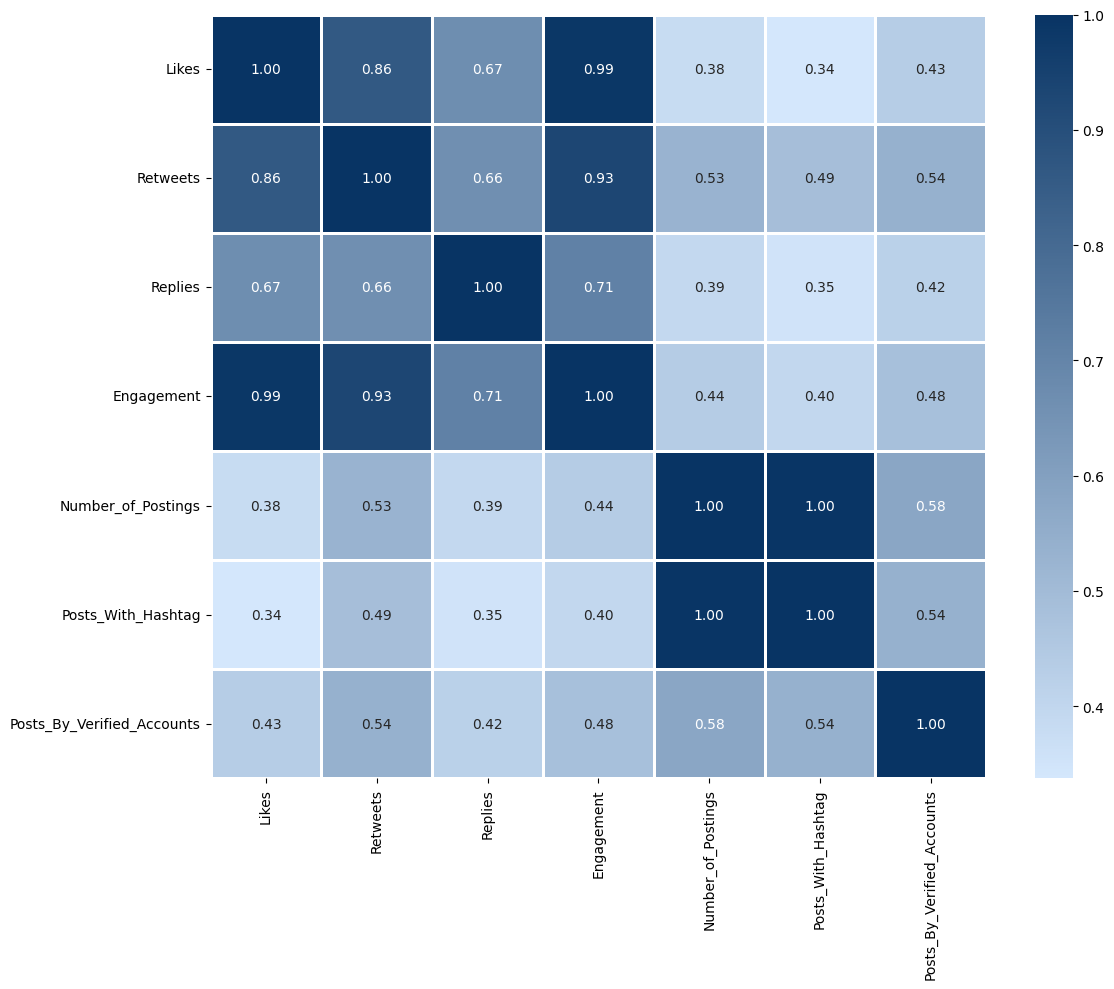

In [46]:
# Create analysis features
df['Date'] = pd.to_datetime(df['Timestamp']).dt.date
df['Has_Hashtag'] = df['Hashtag'].notna().astype(int)
df['Is_Verified'] = (df['Account_Status'] == 'Verified').astype(int)

# Define analysis period
start_date = pd.to_datetime('2019-01-01').date()
end_date = pd.to_datetime('2023-04-10').date()

# Filter data by date range
df_filtered = df[
    (df['Date'] >= start_date) &
    (df['Date'] <= end_date)
].copy()

# Create engagement metric if not available
if 'Engagement' not in df_filtered.columns:
    df_filtered['Engagement'] = (
        df_filtered['Likes']
        + df_filtered['Retweets']
        + df_filtered['Replies']
    )

# Aggregate daily metrics
daily_metrics = (
    df_filtered.groupby('Date')
    .agg(
        Likes=('Likes', 'sum'),
        Retweets=('Retweets', 'sum'),
        Replies=('Replies', 'sum'),
        Engagement=('Engagement', 'sum'),
        Number_of_Postings=('ID', 'count'),
        Posts_With_Hashtag=('Has_Hashtag', 'sum'),
        Posts_By_Verified_Accounts=('Is_Verified', 'sum')
    )
    .reset_index()
)

# Calculate correlations
correlation_matrix = daily_metrics[
    [
        'Likes',
        'Retweets',
        'Replies',
        'Engagement',
        'Number_of_Postings',
        'Posts_With_Hashtag',
        'Posts_By_Verified_Accounts'
    ]
].corr()

# Display results
print('Daily Engagement and Activity Metrics (Filtered Date Range):')
print(daily_metrics.set_index('Date').head().to_string())

print('\nCorrelation Matrix (Daily Aggregation, Filtered Date Range):')
print(correlation_matrix.to_string())

# Create custom color map
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_cmap',
    ['#d4e7fc', '#083464']
)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap=cmap,
    fmt='.2f',
    linewidths=1,
    ax=ax
)

plt.tight_layout()
plt.show()

In [47]:
# Select final output columns
final_columns = [
    'ID',
    'Timestamp',
    'User',
    'Text',
    'Hashtag',
    'Retweets',
    'Likes',
    'Replies',
    'Engagement',
    'Source',
    'Verified_Account',
    'Followers',
    'Following',
    'Cleaned_Source',
    'Account_Status'
]

# Create final dataset
df = df[final_columns].copy()

# Export dataset
output_file = 'Job_Tweets_Cleaned.csv'
df.to_csv(output_file, index=False)

print(f'Final cleaned data saved to "{output_file}"')

Final cleaned data saved to "Job_Tweets_Cleaned.csv"
